In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                           classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import time

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [ ]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

In [ ]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

In [ ]:
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=42, stratify=y_iris
)

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)

# Масштабирование
scaler_compare = StandardScaler()

X_iris_train_scaled = scaler_compare.fit_transform(X_iris_train)
X_iris_test_scaled = scaler_compare.transform(X_iris_test)

X_wine_train_scaled = scaler_compare.fit_transform(X_wine_train)
X_wine_test_scaled = scaler_compare.transform(X_wine_test)

print("Размеры выборок для сравнения:")
print(f"Iris - Обучающая: {X_iris_train_scaled.shape}, Тестовая: {X_iris_test_scaled.shape}")
print(f"Wine - Обучающая: {X_wine_train_scaled.shape}, Тестовая: {X_wine_test_scaled.shape}")


Размеры выборок для сравнения:
Iris - Обучающая: (112, 4), Тестовая: (38, 4)
Wine - Обучающая: (133, 13), Тестовая: (45, 13)


In [ ]:
k_values = [1, 3, 5, 7, 9]
results = []

for k in k_values:
    # Модель для Iris
    knn_iris = KNeighborsClassifier(n_neighbors=k)
    knn_iris.fit(X_iris_train_scaled, y_iris_train)
    y_pred_iris = knn_iris.predict(X_iris_test_scaled)

    # Модель для Wine
    knn_wine = KNeighborsClassifier(n_neighbors=k)
    knn_wine.fit(X_wine_train_scaled, y_wine_train)
    y_pred_wine = knn_wine.predict(X_wine_test_scaled)

    # Метрики для Iris
    iris_accuracy = accuracy_score(y_iris_test, y_pred_iris)
    iris_report = classification_report(y_iris_test, y_pred_iris, output_dict=True)

    # Метрики для Wine
    wine_accuracy = accuracy_score(y_wine_test, y_pred_wine)
    wine_report = classification_report(y_wine_test, y_pred_wine, output_dict=True)

    results.append({
        'k': k,
        'iris_accuracy': iris_accuracy,
        'wine_accuracy': wine_accuracy,
        'iris_precision_weighted': iris_report['weighted avg']['precision'],
        'iris_recall_weighted': iris_report['weighted avg']['recall'],
        'iris_f1_weighted': iris_report['weighted avg']['f1-score'],
        'wine_precision_weighted': wine_report['weighted avg']['precision'],
        'wine_recall_weighted': wine_report['weighted avg']['recall'],
        'wine_f1_weighted': wine_report['weighted avg']['f1-score']
    })

In [ ]:
results_df = pd.DataFrame(results)
print("Сравнительная таблица метрик:")
print(results_df.round(4))

Сравнительная таблица метрик:
   k  iris_accuracy  wine_accuracy  iris_precision_weighted  \
0  1         0.9474         0.9556                   0.9544   
1  3         0.9211         0.9556                   0.9359   
2  5         0.9211         0.9333                   0.9359   
3  7         0.9474         0.9778                   0.9544   
4  9         0.9737         0.9778                   0.9756   

   iris_recall_weighted  iris_f1_weighted  wine_precision_weighted  \
0                0.9474            0.9471                   0.9587   
1                0.9211            0.9200                   0.9587   
2                0.9211            0.9200                   0.9354   
3                0.9474            0.9471                   0.9795   
4                0.9737            0.9736                   0.9795   

   wine_recall_weighted  wine_f1_weighted  
0                0.9556            0.9551  
1                0.9556            0.9551  
2                0.9333            0.9

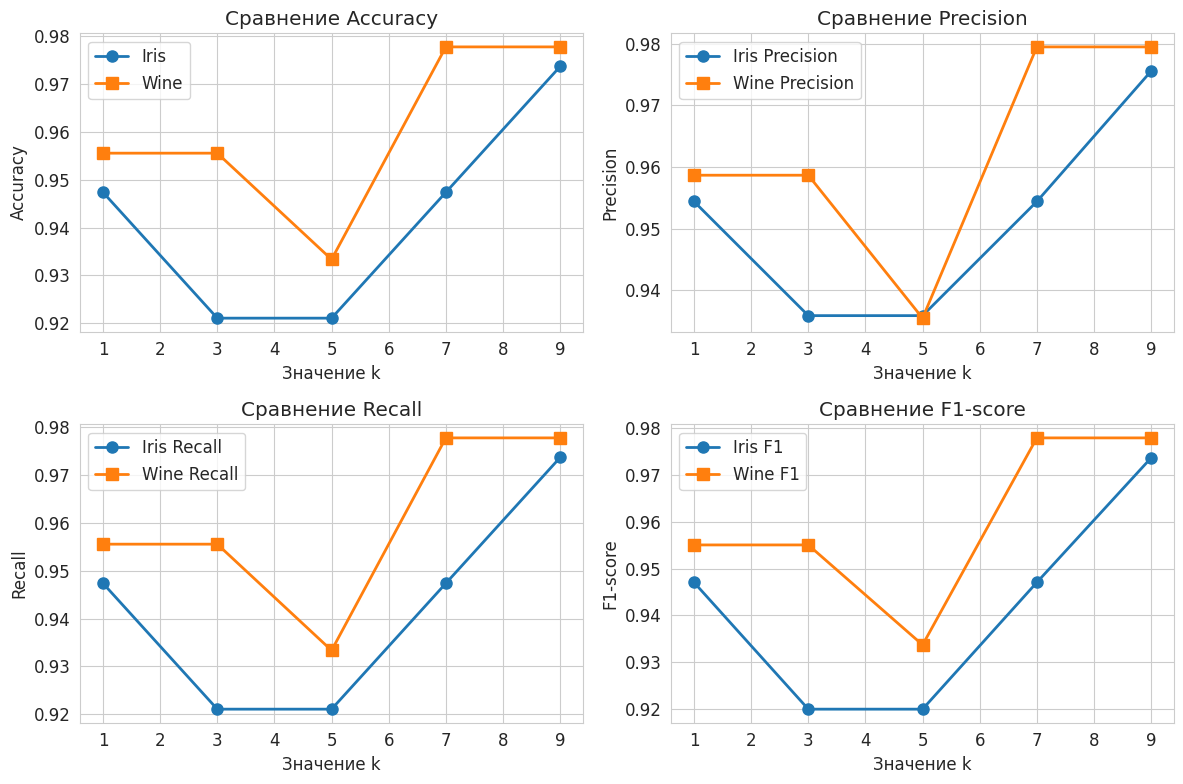

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(results_df['k'], results_df['iris_accuracy'], 'o-', label='Iris', linewidth=2, markersize=8)
plt.plot(results_df['k'], results_df['wine_accuracy'], 's-', label='Wine', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('Accuracy')
plt.title('Сравнение Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(results_df['k'], results_df['iris_precision_weighted'], 'o-', label='Iris Precision', linewidth=2, markersize=8)
plt.plot(results_df['k'], results_df['wine_precision_weighted'], 's-', label='Wine Precision', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('Precision')
plt.title('Сравнение Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(results_df['k'], results_df['iris_recall_weighted'], 'o-', label='Iris Recall', linewidth=2, markersize=8)
plt.plot(results_df['k'], results_df['wine_recall_weighted'], 's-', label='Wine Recall', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('Recall')
plt.title('Сравнение Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(results_df['k'], results_df['iris_f1_weighted'], 'o-', label='Iris F1', linewidth=2, markersize=8)
plt.plot(results_df['k'], results_df['wine_f1_weighted'], 's-', label='Wine F1', linewidth=2, markersize=8)
plt.xlabel('Значение k')
plt.ylabel('F1-score')
plt.title('Сравнение F1-score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import time

k_time_test = 5
time_results = []

# Iris
start_time = time.time()
knn_iris_time = KNeighborsClassifier(n_neighbors=k_time_test)
knn_iris_time.fit(X_iris_train_scaled, y_iris_train)
y_pred_iris_time = knn_iris_time.predict(X_iris_test_scaled)
iris_time = time.time() - start_time

# Wine
start_time = time.time()
knn_wine_time = KNeighborsClassifier(n_neighbors=k_time_test)
knn_wine_time.fit(X_wine_train_scaled, y_wine_train)
y_pred_wine_time = knn_wine_time.predict(X_wine_test_scaled)
wine_time = time.time() - start_time

print("Сравнение времени выполнения (k=5):")
print(f"Iris - Время обучения и предсказания: {iris_time:.4f} сек")
print(f"Wine - Время обучения и предсказания: {wine_time:.4f} сек")
print(f"Отношение времени (Wine/Iris): {wine_time/iris_time:.2f}")

Сравнение времени выполнения (k=5):
Iris - Время обучения и предсказания: 0.0040 сек
Wine - Время обучения и предсказания: 0.0082 сек
Отношение времени (Wine/Iris): 2.04


In [ ]:
print("\n=== АНАЛИЗ РЕЗУЛЬТАТОВ ===")
print("1. ВЛИЯНИЕ РАЗМЕРНОСТИ ДАННЫХ:")
print(f"   Iris: {X_iris.shape[1]} признаков, {X_iris.shape[0]} образцов")
print(f"   Wine: {X_wine.shape[1]} признаков, {X_wine.shape[0]} образцов")
print("   Вывод: Wine имеет большую размерность, что может требовать больше данных")

print("\n2. СТАБИЛЬНОСТЬ РЕЗУЛЬТАТОВ:")
best_k_iris = results_df.loc[results_df['iris_accuracy'].idxmax(), 'k']
best_k_wine = results_df.loc[results_df['wine_accuracy'].idxmax(), 'k']
print(f"   Лучшее k для Iris: {best_k_iris}")
print(f"   Лучшее k для Wine: {best_k_wine}")

print("\n3. ПРЕИМУЩЕСТВА И НЕДОСТАТКИ k-NN:")
print("   Преимущества:")
print("   - Простота реализации и интерпретации")
print("   - Не требует обучения (ленивый алгоритм)")
print("   - Хорошо работает на небольших наборах данных")
print("   Недостатки:")
print("   - Чувствительность к масштабированию")
print("   - Медленный на больших наборах данных")
print("   - Чувствительность к нерелевантным признакам")

print("\n4. РЕКОМЕНДАЦИИ ПО ВЫБОРУ k:")
print("   Для Iris: k = 3-7 (меньшая размерность, четкие кластеры)")
print("   Для Wine: k = 5-9 (большая размерность, требуется сглаживание)")


=== АНАЛИЗ РЕЗУЛЬТАТОВ ===
1. ВЛИЯНИЕ РАЗМЕРНОСТИ ДАННЫХ:
   Iris: 4 признаков, 150 образцов
   Wine: 13 признаков, 178 образцов
   Вывод: Wine имеет большую размерность, что может требовать больше данных

2. СТАБИЛЬНОСТЬ РЕЗУЛЬТАТОВ:
   Лучшее k для Iris: 9
   Лучшее k для Wine: 7

3. ПРЕИМУЩЕСТВА И НЕДОСТАТКИ k-NN:
   Преимущества:
   - Простота реализации и интерпретации
   - Не требует обучения (ленивый алгоритм)
   - Хорошо работает на небольших наборах данных
   Недостатки:
   - Чувствительность к масштабированию
   - Медленный на больших наборах данных
   - Чувствительность к нерелевантным признакам

4. РЕКОМЕНДАЦИИ ПО ВЫБОРУ k:
   Для Iris: k = 3-7 (меньшая размерность, четкие кластеры)
   Для Wine: k = 5-9 (большая размерность, требуется сглаживание)
